# Food Allergy Classification using Logistic Regression

## Load the data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('https://claproduction.s3.eu-west-3.amazonaws.com/DataScience/3_classical_ml/food-allergy-analysis-Zenodo.csv')
df.head()

,SUBJECT_ID,BIRTH_YEAR,GENDER_FACTOR,RACE_FACTOR,ETHNICITY_FACTOR,PAYER_FACTOR,ATOPIC_MARCH_COHORT,AGE_START_YEARS,AGE_END_YEARS,SHELLFISH_ALG_START,...,CASHEW_ALG_END,ATOPIC_DERM_START,ATOPIC_DERM_END,ALLERGIC_RHINITIS_START,ALLERGIC_RHINITIS_END,ASTHMA_START,ASTHMA_END,FIRST_ASTHMARX,LAST_ASTHMARX,NUM_ASTHMARX
0,1,2006,S1 - Female,R1 - Black,E0 - Non-Hispanic,P1 - Medicaid,False,0.093087,3.164956,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1994,S1 - Female,R0 - White,E0 - Non-Hispanic,P0 - Non-Medicaid,False,12.232717,18.880219,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.262834,18.880219,2.0
2,3,2006,S0 - Male,R0 - White,E1 - Hispanic,P0 - Non-Medicaid,True,0.010951,6.726899,NaN,...,NaN,4.884326,NaN,3.917864,6.157426,5.127995,NaN,1.404517,6.157426,4.0
3,4,2004,S0 - Male,R4 - Unknown,E1 - Hispanic,P0 - Non-Medicaid,False,2.398357,9.111567,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2006,S1 - Female,R1 - Black,E0 - Non-Hispanic,P0 - Non-Medicaid,False,0.013689,6.193018,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(333200, 50)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333200 entries, 0 to 333199
Data columns (total 50 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   SUBJECT_ID               333200 non-null  int64  
 1   BIRTH_YEAR               333200 non-null  int64  
 2   GENDER_FACTOR            333200 non-null  object 
 3   RACE_FACTOR              333200 non-null  object 
 4   ETHNICITY_FACTOR         333200 non-null  object 
 5   PAYER_FACTOR             333200 non-null  object 
 6   ATOPIC_MARCH_COHORT      333200 non-null  bool   
 7   AGE_START_YEARS          333200 non-null  float64
 8   AGE_END_YEARS            333200 non-null  float64
 9   SHELLFISH_ALG_START      5246 non-null    float64
 10  SHELLFISH_ALG_END        1051 non-null    float64
 11  FISH_ALG_START           1796 non-null    float64
 12  FISH_ALG_END             527 non-null     float64
 13  MILK_ALG_START           7289 non-null    float64
 14  MILK

In [6]:
df.isnull().sum()

,0
SUBJECT_ID,0
BIRTH_YEAR,0
GENDER_FACTOR,0
RACE_FACTOR,0
ETHNICITY_FACTOR,0
PAYER_FACTOR,0
ATOPIC_MARCH_COHORT,0
AGE_START_YEARS,0
AGE_END_YEARS,0
SHELLFISH_ALG_START,327954


## Create the target variable

There's no ready-made target column so I'll create one. If any of the food allergy start columns has a value, the patient has a food allergy.

In [7]:
food_allergy_cols = [
    'SHELLFISH_ALG_START', 'FISH_ALG_START', 'MILK_ALG_START', 'SOY_ALG_START',
    'EGG_ALG_START', 'WHEAT_ALG_START', 'PEANUT_ALG_START', 'SESAME_ALG_START',
    'TREENUT_ALG_START', 'WALNUT_ALG_START', 'PECAN_ALG_START', 'PISTACH_ALG_START',
    'ALMOND_ALG_START', 'BRAZIL_ALG_START', 'HAZELNUT_ALG_START', 'CASHEW_ALG_START'
]

df['HAS_FOOD_ALLERGY'] = df[food_allergy_cols].notna().any(axis=1).astype(int)
df['HAS_FOOD_ALLERGY'].value_counts()

,count
HAS_FOOD_ALLERGY,
0,310589
1,22611


## Feature Engineering

In [8]:
# derive some useful features from the existing columns
df['HAS_ASTHMA'] = df['ASTHMA_START'].notna().astype(int)
df['HAS_ECZEMA'] = df['ATOPIC_DERM_START'].notna().astype(int)
df['HAS_RHINITIS'] = df['ALLERGIC_RHINITIS_START'].notna().astype(int)
df['AGE_SPAN'] = df['AGE_END_YEARS'] - df['AGE_START_YEARS']

## EDA

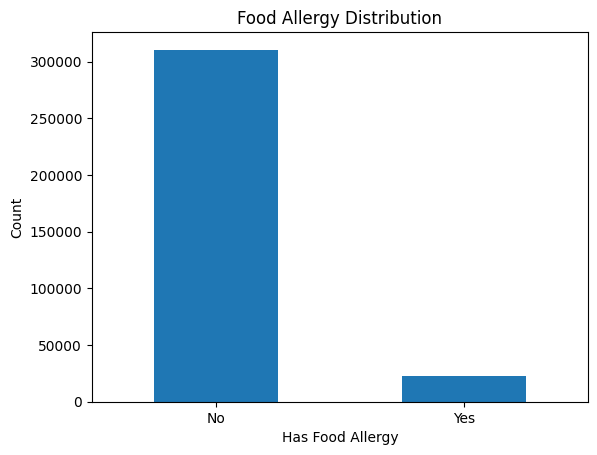

In [9]:
df['HAS_FOOD_ALLERGY'].value_counts().plot(kind='bar')
plt.title('Food Allergy Distribution')
plt.xlabel('Has Food Allergy')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['No','Yes'], rotation=0)
plt.show()

In [10]:
df[['AGE_START_YEARS', 'AGE_SPAN', 'NUM_ASTHMARX', 'HAS_FOOD_ALLERGY']].corr()

,AGE_START_YEARS,AGE_SPAN,NUM_ASTHMARX,HAS_FOOD_ALLERGY
AGE_START_YEARS,1.000000,-0.046611,-0.057426,-0.068617
AGE_SPAN,-0.046611,1.000000,0.229800,0.017407
NUM_ASTHMARX,-0.057426,0.229800,1.000000,0.150253
HAS_FOOD_ALLERGY,-0.068617,0.017407,0.150253,1.000000


## Prepare features and split the data

In [11]:
features = [
    'AGE_START_YEARS', 'AGE_SPAN', 'ATOPIC_MARCH_COHORT',
    'HAS_ASTHMA', 'HAS_ECZEMA', 'HAS_RHINITIS', 'NUM_ASTHMARX'
]

X = df[features]
y = df['HAS_FOOD_ALLERGY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(266560, 7) (66640, 7)


## Train the model

In [12]:
# handle missing values and scale
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Evaluate the model

In [14]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     62075
           1       0.64      0.00      0.01      4565

    accuracy                           0.93     66640
   macro avg       0.78      0.50      0.49     66640
weighted avg       0.91      0.93      0.90     66640



In [15]:
confusion_matrix(y_test, y_pred)

array([[62063,    12],
       [ 4544,    21]])

In [16]:
y_prob = model.predict_proba(X_test)[:, 1]
print('AUC-ROC score:', roc_auc_score(y_test, y_prob))

AUC-ROC score: 0.7006255108671056


## Feature importance

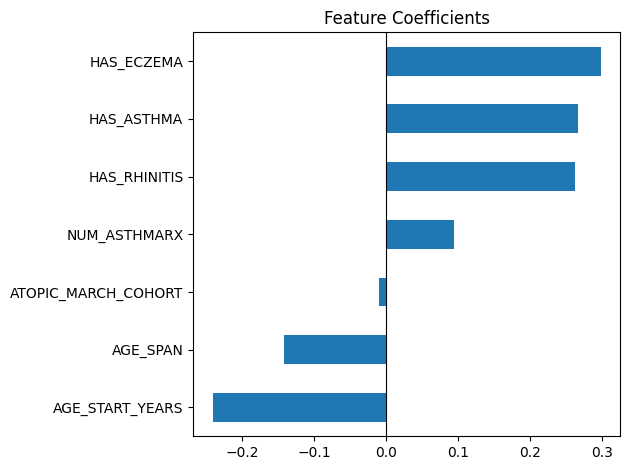

In [17]:
coefs = pd.Series(model.coef_[0], index=features).sort_values()
coefs.plot(kind='barh')
plt.title('Feature Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()